In [1]:
!git clone https://github.com/SenuraSudusinghe/deep-learning-image-classification

Cloning into 'deep-learning-image-classification'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 33 (delta 6), reused 15 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 1.75 MiB | 26.70 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

drive_path = "/content/drive/MyDrive"

print("My Drive contents:")
print(os.listdir(drive_path))

My Drive contents:
['Colab Notebooks', 'Getting started.pdf', 'IMG-20230716-WA0015.jpg', 'google form', 'Untitled presentation.gslides', 'Group project EAP.pptx', 'D420409640a9e04c08491f8c0c6b43635.png', 'inbound5136564411442397170.jpg', 'spmassigment2.drawio', 'Untitled Diagramswim.drawio.png', 'Untitled Diagram (3).drawio', 'relational scema.drawio', 'Assessment.gform', 'styles.css', 'oocClassDiagram.drawio', 'Untitled Diagram (2).drawio', 'my', 'Untitled form.gform', 'Untitled Diagram (1).drawio', 'admin 3.drawio', 'admin comu.drawio', 'IT23309524.drawio', 'inbound7204722940939076426.jpg', 'petshop.drawio', 'ICHEMC 3rd floor drawing.dwg', 'receipt-1.pdf', 'evindu (1).jpg', 'evindu.jpg', 'DSA', 'life fashion.drawio', 'Evindu CV (1).pdf', 'Evindu CV.pdf', 'Authorization to Collect Cheque.docx', 'csse.drawio.png', 'class.drawio', 'Untitled Diagram.drawio', 'podcast', ' fast food 2.gform', 'greenstep', 'Assignment', 'Assingment 2', 'EVINDU ISHEN - CV.pdf', 'Evindu(SLIIT).pdf', 'Evindu(S

In [4]:
import os

project_path = "/content/drive/MyDrive/Deep-Learning-Image-Classification"

print("Project folder contents:")
print(os.listdir(project_path))

Project folder contents:
['Dataset', 'Models', 'Results', 'Figures', 'Reports', 'Shared Resources', 'Notebooks']


In [5]:
dataset_path = "/content/drive/MyDrive/Deep-Learning-Image-Classification/Dataset"

print("Dataset folder contents:")
print(os.listdir(dataset_path))

Dataset folder contents:
['val', 'train', 'test']


In [6]:
for split in ["train", "val", "test"]:
    split_path = os.path.join(dataset_path, split)

    print(f"\n{split.upper()} SET")
    print("-" * 30)

    classes = sorted(os.listdir(split_path))

    for class_name in classes:
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            image_count = len(os.listdir(class_path))
            print(f"{class_name}: {image_count} images")


TRAIN SET
------------------------------
buildings: 1972 images
forest: 2044 images
glacier: 2164 images
mountain: 2261 images
sea: 2047 images
street: 2144 images

VAL SET
------------------------------
buildings: 219 images
forest: 227 images
glacier: 240 images
mountain: 251 images
sea: 227 images
street: 238 images

TEST SET
------------------------------
buildings: 437 images
forest: 474 images
glacier: 553 images
mountain: 525 images
sea: 510 images
street: 501 images


Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


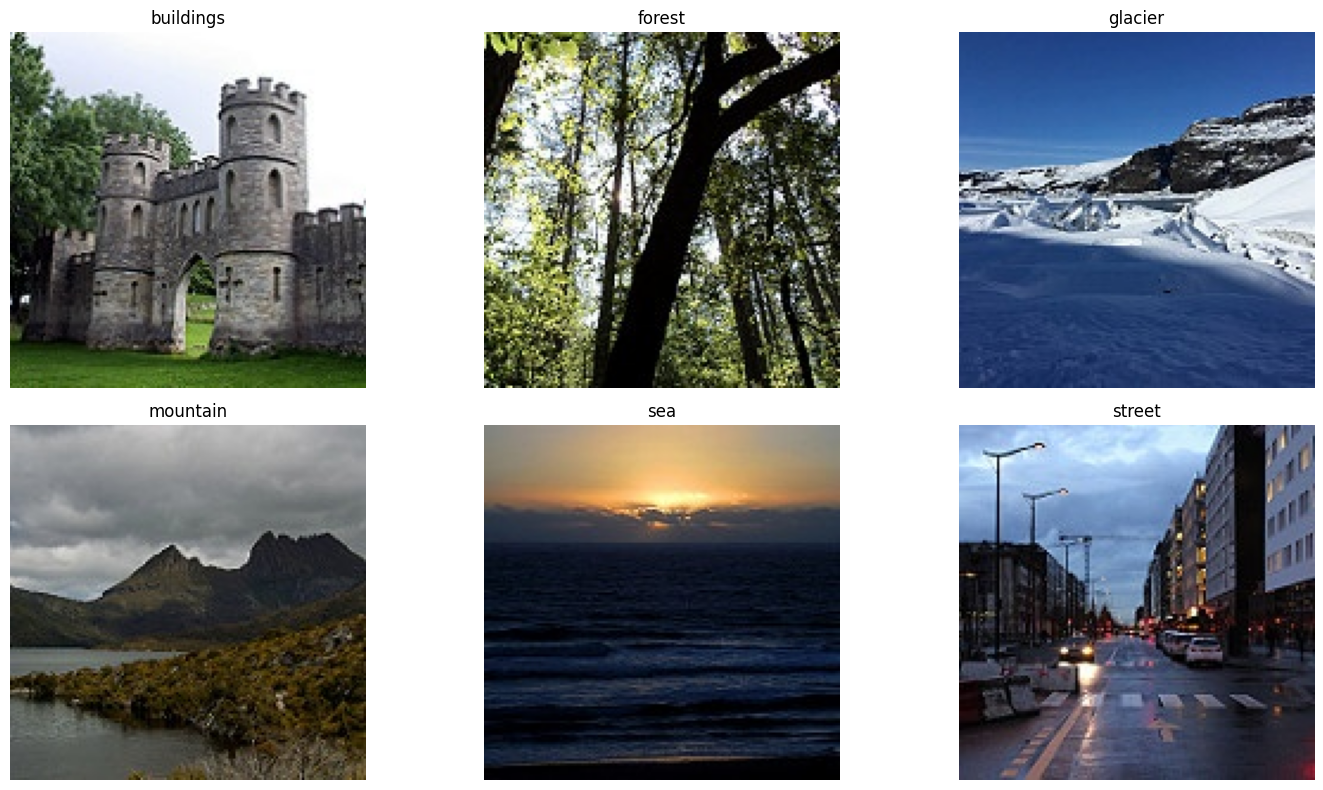

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Get the class names from the training folder
train_path = os.path.join(dataset_path, "train")

classes = sorted([
    folder for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
])

print("Classes:", classes)

# Display one random image from each class
plt.figure(figsize=(15, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_file = random.choice(image_files)
    image_path = os.path.join(class_path, image_file)

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
from collections import Counter
from PIL import Image

# Check image properties in the training dataset
dimension_counter = Counter()
format_counter = Counter()
corrupted_images = []

for class_name in classes:
    class_path = os.path.join(train_path, class_name)

    for filename in os.listdir(class_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(class_path, filename)

            try:
                with Image.open(image_path) as img:
                    dimension_counter[img.size] += 1
                    format_counter[img.format] += 1
            except Exception:
                corrupted_images.append(image_path)

print("Most common image dimensions:")
for dimension, count in dimension_counter.most_common(10):
    print(f"{dimension}: {count}")

print("\nImage formats:")
for image_format, count in format_counter.items():
    print(f"{image_format}: {count}")

print("\nCorrupted/unreadable images:", len(corrupted_images))

Most common image dimensions:
(150, 150): 12590
(150, 113): 7
(150, 135): 3
(150, 108): 2
(150, 111): 2
(150, 143): 2
(150, 146): 2
(150, 142): 2
(150, 123): 2
(150, 144): 2

Image formats:
JPEG: 12632

Corrupted/unreadable images: 0


Split     Class  Images
train buildings    1972
train    forest    2044
train   glacier    2164
train  mountain    2261
train       sea    2047
train    street    2144
  val buildings     219
  val    forest     227
  val   glacier     240
  val  mountain     251
  val       sea     227
  val    street     238
 test buildings     437
 test    forest     474
 test   glacier     553
 test  mountain     525
 test       sea     510
 test    street     501


<Figure size 1200x600 with 0 Axes>

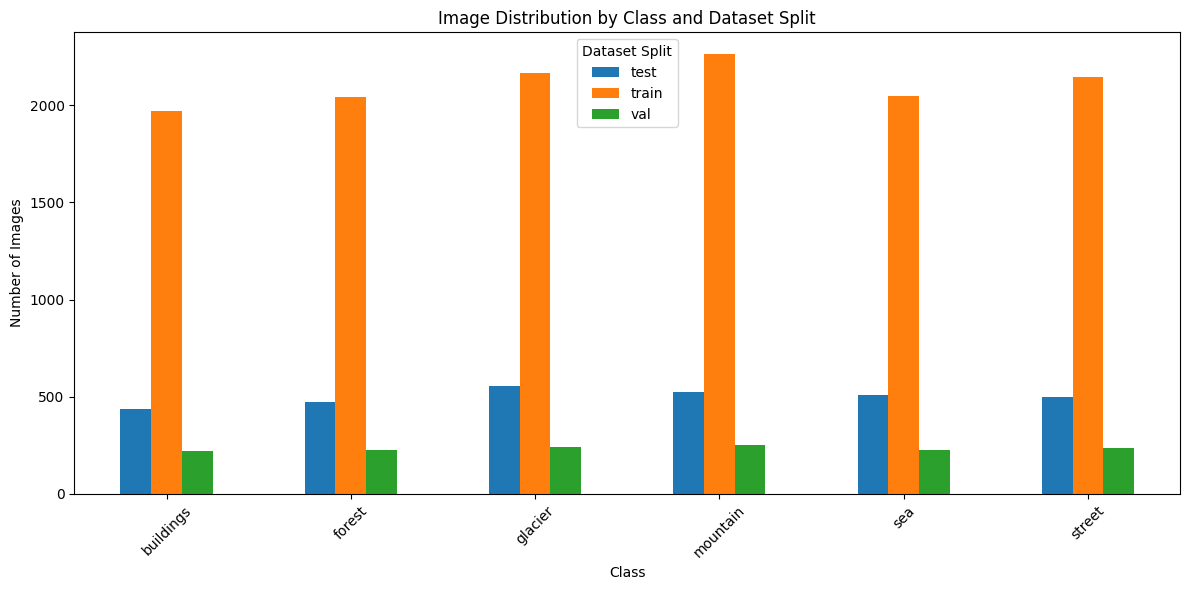

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Count images in each class for each split
distribution = []

for split in ["train", "val", "test"]:
    split_path = os.path.join(dataset_path, split)

    for class_name in classes:
        class_path = os.path.join(split_path, class_name)

        image_count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        distribution.append({
            "Split": split,
            "Class": class_name,
            "Images": image_count
        })

distribution_df = pd.DataFrame(distribution)

print(distribution_df.to_string(index=False))

# Plot class distribution
plt.figure(figsize=(12, 6))

distribution_df.pivot(
    index="Class",
    columns="Split",
    values="Images"
).plot(kind="bar", figsize=(12, 6))

plt.title("Image Distribution by Class and Dataset Split")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.legend(title="Dataset Split")
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

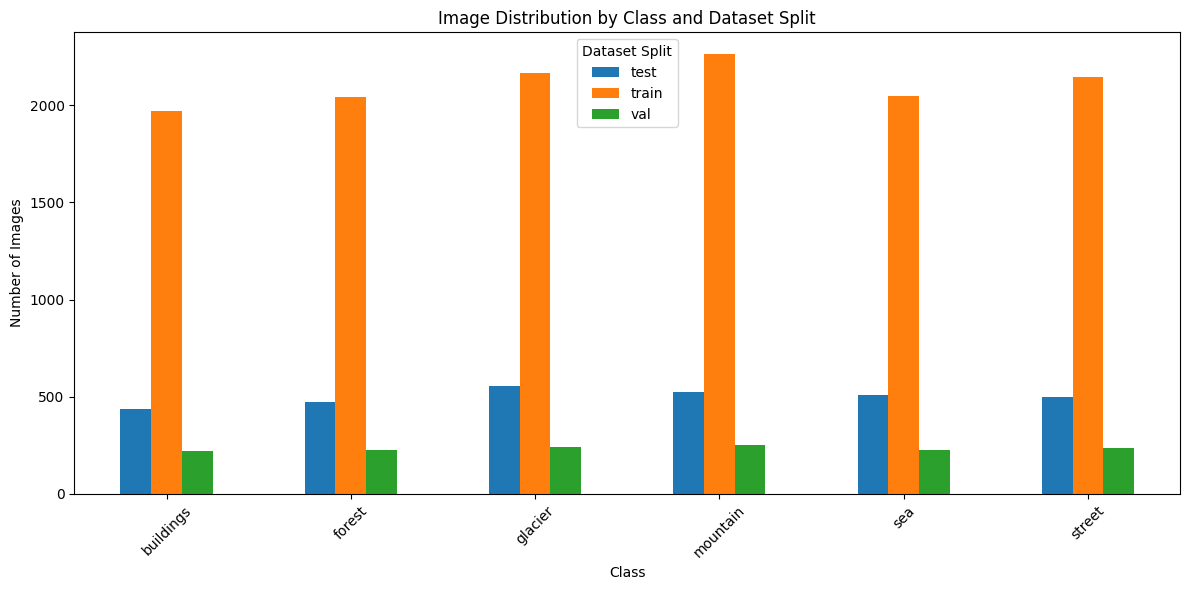

Saved successfully:
/content/drive/MyDrive/Deep-Learning-Image-Classification/Results/dataset_class_distribution.csv
/content/drive/MyDrive/Deep-Learning-Image-Classification/Figures/dataset_class_distribution.png


In [10]:
# Create project output folders if they don't already exist
figures_path = "/content/drive/MyDrive/Deep-Learning-Image-Classification/Figures"
results_path = "/content/drive/MyDrive/Deep-Learning-Image-Classification/Results"

os.makedirs(figures_path, exist_ok=True)
os.makedirs(results_path, exist_ok=True)

# Save the distribution table
distribution_csv = os.path.join(
    results_path,
    "dataset_class_distribution.csv"
)

distribution_df.to_csv(distribution_csv, index=False)

# Save the graph
figure_path = os.path.join(
    figures_path,
    "dataset_class_distribution.png"
)

plt.figure(figsize=(12, 6))

distribution_df.pivot(
    index="Class",
    columns="Split",
    values="Images"
).plot(kind="bar", figsize=(12, 6))

plt.title("Image Distribution by Class and Dataset Split")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.legend(title="Dataset Split")
plt.tight_layout()

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved successfully:")
print(distribution_csv)
print(figure_path)

In [11]:
for split in ["train", "val", "test"]:
    split_path = os.path.join(dataset_path, split)

    dimension_counter = Counter()

    for class_name in classes:
        class_path = os.path.join(split_path, class_name)

        for filename in os.listdir(class_path):
            if filename.lower().endswith((".jpg", ".jpeg", ".png")):
                image_path = os.path.join(class_path, filename)

                try:
                    with Image.open(image_path) as img:
                        dimension_counter[img.size] += 1
                except Exception:
                    pass

    total_images = sum(dimension_counter.values())

    print(f"\n{split.upper()} SET")
    print(f"Total images: {total_images}")

    for dimension, count in dimension_counter.most_common(10):
        percentage = (count / total_images) * 100
        print(f"{dimension}: {count} ({percentage:.2f}%)")


TRAIN SET
Total images: 12632
(150, 150): 12590 (99.67%)
(150, 113): 7 (0.06%)
(150, 135): 3 (0.02%)
(150, 108): 2 (0.02%)
(150, 111): 2 (0.02%)
(150, 143): 2 (0.02%)
(150, 146): 2 (0.02%)
(150, 142): 2 (0.02%)
(150, 123): 2 (0.02%)
(150, 144): 2 (0.02%)

VAL SET
Total images: 1402
(150, 150): 1396 (99.57%)
(150, 136): 1 (0.07%)
(150, 105): 1 (0.07%)
(150, 149): 1 (0.07%)
(150, 111): 1 (0.07%)
(150, 134): 1 (0.07%)
(150, 141): 1 (0.07%)

TEST SET
Total images: 3000
(150, 150): 2993 (99.77%)
(150, 141): 1 (0.03%)
(150, 110): 1 (0.03%)
(150, 76): 1 (0.03%)
(150, 149): 1 (0.03%)
(150, 72): 1 (0.03%)
(150, 131): 1 (0.03%)
(150, 81): 1 (0.03%)


In [1]:
import tensorflow as tf
import keras
import numpy as np
import sklearn
import matplotlib

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)

print("\nGPU devices:")
print(tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
Keras: 3.13.2
NumPy: 2.1.3
Scikit-learn: 1.6.1
Matplotlib: 3.10.0

GPU devices:
[]


In [1]:
!git clone https://github.com/SenuraSudusinghe/deep-learning-image-classification.git

Cloning into 'deep-learning-image-classification'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 108 (delta 42), reused 63 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (108/108), 6.86 MiB | 28.19 MiB/s, done.
Resolving deltas: 100% (42/42), done.


In [2]:
%cd /content/deep-learning-image-classification

/content/deep-learning-image-classification


In [3]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [4]:
!find . -maxdepth 2 -type f | sort

./dataset/.gitkeep
./figures/.gitkeep
./.git/config
./.git/description
./.git/HEAD
./.git/index
./.git/packed-refs
./models/.gitkeep
./notebooks/data_preprocessing.ipynb
./notebooks/dataset_analysis.ipynb
./notebooks/.gitkeep
./notebooks/mobilenetv2.ipynb
./README.md
./reports/EDA_Report.docx
./reports/.gitkeep
./requirements.txt
./results/.gitkeep
./src/.gitkeep


In [5]:
!git branch -a

* main
  remotes/origin/Feature/deep-cnn
  remotes/origin/Feature/mobilenetv2
  remotes/origin/Feature/pipelineupdate
  remotes/origin/HEAD -> origin/main
  remotes/origin/feature/deep-cnn
  remotes/origin/feature/mobilenetv2
  remotes/origin/feature/simple-cnn
  remotes/origin/feature/vgg16
  remotes/origin/main


In [6]:
!git log --oneline --decorate -10 origin/feature/simple-cnn

99c8472 (origin/feature/simple-cnn, origin/feature/mobilenetv2, origin/feature/deep-cnn) Initial commit
7f07511 Initial Commit
ba8f0c5 Delete dataset
e49df80 Create dataset
dcb2164 Initial commit


In [7]:
!git checkout -b feature/simple-cnn --track origin/feature/simple-cnn

branch 'feature/simple-cnn' set up to track 'origin/feature/simple-cnn'.
Switched to a new branch 'feature/simple-cnn'


In [8]:
!git status

On branch feature/simple-cnn
Your branch is up to date with 'origin/feature/simple-cnn'.

nothing to commit, working tree clean


In [9]:
import shutil
import os

source_notebook = "/content/SimpleCNN.ipynb"
repo_notebook = "/content/deep-learning-image-classification/notebooks/SimpleCNN.ipynb"

print("Checking notebook location...")
print("Exists:", os.path.exists(source_notebook))

Checking notebook location...
Exists: False


In [10]:
import os

matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "SimpleCNN.ipynb" in files:
        matches.append(os.path.join(root, "SimpleCNN.ipynb"))

print("SimpleCNN.ipynb locations:")
for path in matches:
    print(path)

SimpleCNN.ipynb locations:
/content/drive/MyDrive/Colab Notebooks/SimpleCNN.ipynb
